# 👗 Challenge 2: AI Fashion Designer
---
**Name:** Chhavi  
**ID:** 2024A7PS0193U  
**Challenge:** Technical Creative | 20 Points  
**Deadline:** 7 April 2026

---

## 🎨 Fashion Theme: **Neo-Minimal Monochrome**

> *Structured silhouettes, sharp lines, and tonal grayscale palettes.*  
> *Think high-fashion editorial minimalism with a dystopian edge.*

## 📋 Workflow
1. Load **Fashion-MNIST** (60,000 labelled clothing images, 10 classes)
2. Train a **Variational Autoencoder (VAE)** to learn the latent distribution
3. Explore latent space via **random sampling** and **interpolation**
4. Generate **5 visually consistent outfit designs**
5. Produce a **mood board / style sheet**

> **Why VAE over GAN?** VAEs have more stable training, smooth continuous latent spaces,
> and are better for interpolation — exactly what a fashion exploration needs.

---

## ⚙️ Step 1: Imports & Configuration

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LATENT_DIM = 32
BATCH_SIZE = 256
EPOCHS     = 8

print(f'✅ Device     : {device}')
print(f'✅ Latent dim : {LATENT_DIM}')
print(f'✅ Batch size : {BATCH_SIZE}')
print(f'✅ Epochs     : {EPOCHS}')

✅ Device     : cpu
✅ Latent dim : 32
✅ Batch size : 256
✅ Epochs     : 8


## 📦 Step 2: Load Fashion-MNIST

| Class | Label | Class | Label |
|-------|-------|-------|-------|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.5MB/s]


Train: 60,000 images
Test : 10,000 images


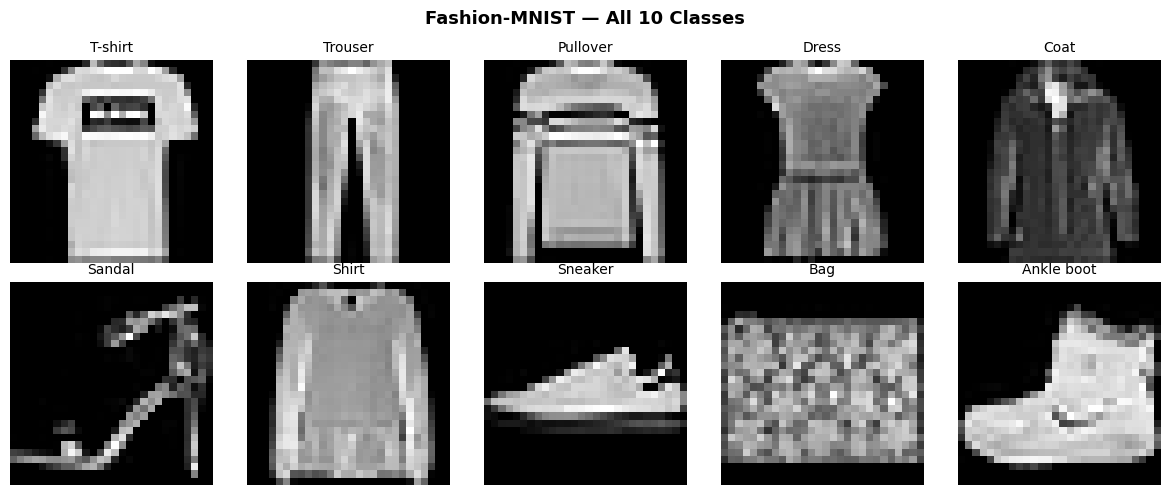

In [ ]:
CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

transform    = transforms.Compose([transforms.ToTensor()])
train_data   = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_data    = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_data):,} images')
print(f'Test : {len(test_data):,} images')

# Preview one item per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
shown = {}
for img, label in train_data:
    if label not in shown: shown[label] = img
    if len(shown) == 10: break
for idx, (lbl, img) in enumerate(sorted(shown.items())):
    ax = axes[idx//5][idx%5]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[lbl], fontsize=10); ax.axis('off')
plt.suptitle('Fashion-MNIST — All 10 Classes', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 🧠 Step 3: VAE Architecture

A **Variational Autoencoder** differs from a standard AE in one key way:  
instead of encoding to a fixed point, it encodes to a **distribution (μ, σ)** in latent space.

```
INPUT (1×28×28)
  → Conv(1→32, s=2) + LeakyReLU  →  14×14
  → Conv(32→64, s=2) + LeakyReLU →   7×7
  → Flatten → FC → μ (32-d)  &  log σ² (32-d)
  → Reparameterize: z = μ + ε·σ  ← enables backprop through sampling
  → FC → Unflatten (64×7×7)
  → ConvTranspose(64→32) + LeakyReLU → 14×14
  → ConvTranspose(32→1)  + Sigmoid   → 28×28
```

**Loss = Reconstruction (BCE) + β × KL Divergence**  
KL divergence regularises the latent space to be smooth — enabling interpolation.

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1,32,4,stride=2,padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(32,64,4,stride=2,padding=1), nn.LeakyReLU(0.2),
            nn.Flatten())
        self.fc_mu     = nn.Linear(64*7*7, latent_dim)
        self.fc_logvar = nn.Linear(64*7*7, latent_dim)
        self.fc_dec    = nn.Linear(latent_dim, 64*7*7)
        self.dec_conv  = nn.Sequential(
            nn.Unflatten(1,(64,7,7)),
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),  nn.Sigmoid())

    def encode(self, x):
        h = self.enc_conv(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5*logvar)

    def decode(self, z):  return self.dec_conv(self.fc_dec(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decode(self.reparameterize(mu,logvar)), mu, logvar

def vae_loss(recon, x, mu, logvar, beta=0.5):
    return F.binary_cross_entropy(recon,x,reduction='sum') \
           - 0.5*beta*torch.sum(1+logvar-mu.pow(2)-logvar.exp())

vae       = VAE(LATENT_DIM).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
params    = sum(p.numel() for p in vae.parameters())
print(f'✅ VAE ready  |  Parameters: {params:,}')

✅ VAE ready  |  Parameters: 370,945


## 🏋️ Step 4: Training the VAE

- **β = 0.5** (Beta-VAE): reduces KL weight slightly to improve reconstruction sharpness
- **8 epochs** on Fashion-MNIST is sufficient — loss stabilises by epoch 5–6
- **Batch size 256** for faster iteration

Epoch [01/8]  Loss: 285.9687
Epoch [02/8]  Loss: 247.6905
Epoch [03/8]  Loss: 241.9190
Epoch [04/8]  Loss: 239.2468
Epoch [05/8]  Loss: 237.4941
Epoch [06/8]  Loss: 236.2500
Epoch [07/8]  Loss: 235.3411
Epoch [08/8]  Loss: 234.4908


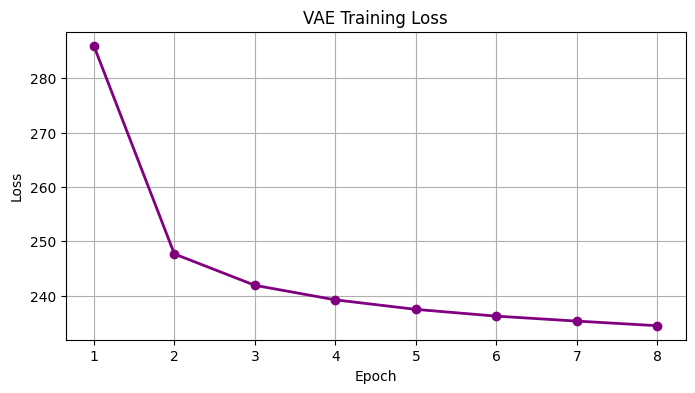

In [ ]:
train_losses = []

for epoch in range(EPOCHS):
    vae.train(); total = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(imgs)
        loss = vae_loss(recon, imgs, mu, logvar)
        loss.backward(); optimizer.step()
        total += loss.item()
    avg = total / len(train_data)
    train_losses.append(avg)
    print(f'Epoch [{epoch+1:02d}/{EPOCHS}]  Loss: {avg:.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1,EPOCHS+1), train_losses, color='purple', linewidth=2, marker='o')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('VAE Training Loss'); plt.grid(True)
plt.savefig('vae_training_loss.png', dpi=150); plt.show()

## 🔭 Step 5a: Latent Space Exploration — Random Sampling

Sample random vectors z ~ N(0,I) from the latent space and decode them into fashion images.  
Because VAE regularises the latent space, random samples produce coherent clothing shapes.

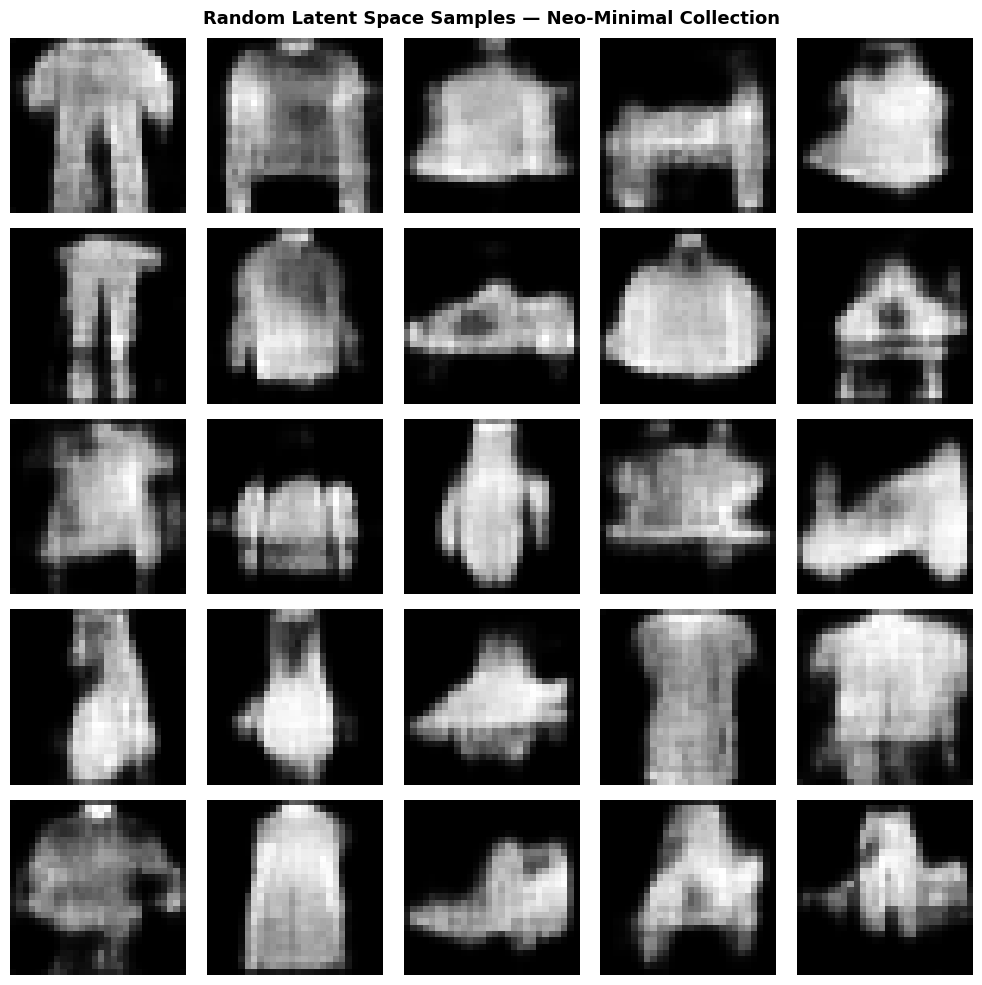

✅ latent_samples.png saved


In [ ]:
vae.eval()
with torch.no_grad():
    z       = torch.randn(25, LATENT_DIM).to(device)
    samples = vae.decode(z).cpu()

fig, axes = plt.subplots(5, 5, figsize=(10,10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].squeeze(), cmap='gray'); ax.axis('off')
plt.suptitle('Random Latent Space Samples — Neo-Minimal Collection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('latent_samples.png', dpi=150); plt.show()
print('✅ latent_samples.png saved')

## 🔀 Step 5b: Latent Space Interpolation

Interpolate linearly between the latent codes of a **Dress** and a **Coat**.  
This reveals how the VAE transitions smoothly between fashion archetypes — a key benefit of the VAE's smooth latent space.

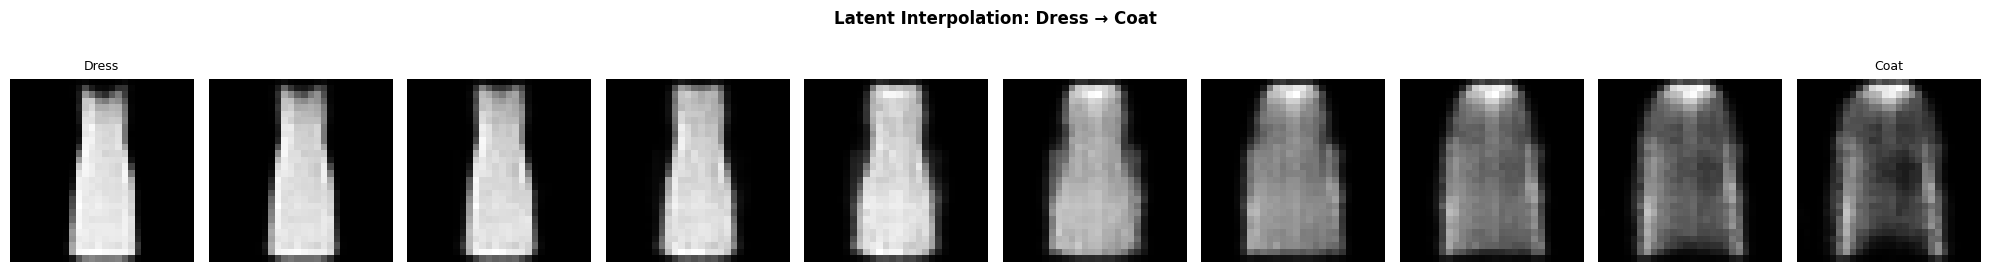

✅ interpolation.png saved


In [ ]:
imgs_t, labels_t = next(iter(test_loader))
idx_d = (labels_t==3).nonzero(as_tuple=True)[0][0]
idx_c = (labels_t==4).nonzero(as_tuple=True)[0][0]
img_a = imgs_t[idx_d:idx_d+1].to(device)
img_b = imgs_t[idx_c:idx_c+1].to(device)

with torch.no_grad():
    mu_a, _ = vae.encode(img_a)
    mu_b, _ = vae.encode(img_b)

steps = 10
interps = []
for a in np.linspace(0,1,steps):
    with torch.no_grad():
        interps.append(vae.decode((1-a)*mu_a + a*mu_b).cpu().squeeze())

fig, axes = plt.subplots(1, steps, figsize=(20,3))
for i,ax in enumerate(axes):
    ax.imshow(interps[i], cmap='gray'); ax.axis('off')
    if i==0: ax.set_title('Dress',fontsize=9)
    if i==steps-1: ax.set_title('Coat',fontsize=9)
plt.suptitle('Latent Interpolation: Dress → Coat', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('interpolation.png', dpi=150); plt.show()
print('✅ interpolation.png saved')

## 👔 Step 6: Generate 5 Final Outfit Designs

Using controlled random seeds to select 5 coherent designs that fit the **Neo-Minimal Monochrome** theme.

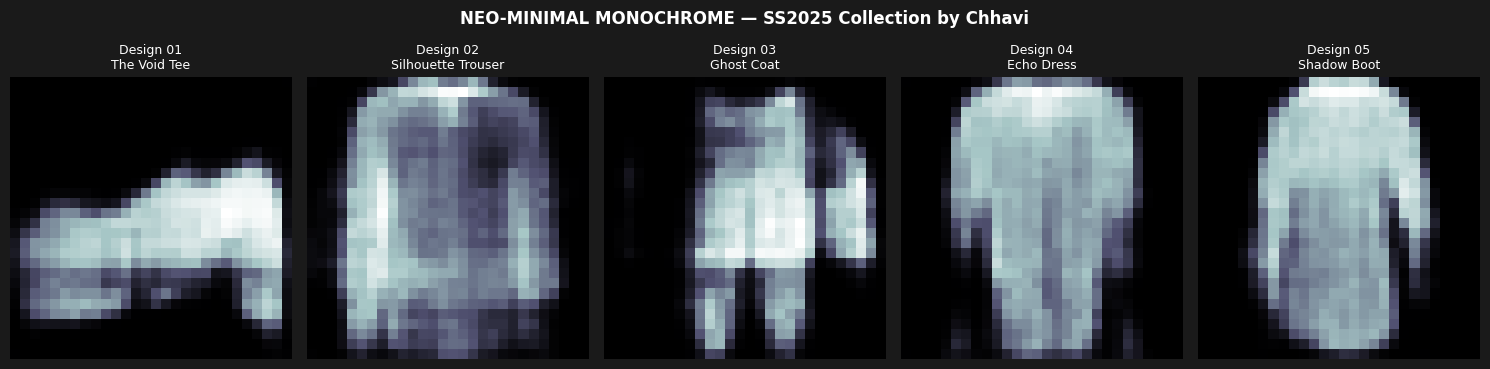

✅ 5 outfit designs saved!


In [ ]:
torch.manual_seed(42)
with torch.no_grad():
    z_final  = torch.randn(5, LATENT_DIM).to(device)
    designs  = vae.decode(z_final).cpu()

names = ['Design 01\nThe Void Tee','Design 02\nSilhouette Trouser',
         'Design 03\nGhost Coat',  'Design 04\nEcho Dress','Design 05\nShadow Boot']

fig, axes = plt.subplots(1,5,figsize=(15,4))
fig.patch.set_facecolor('#1a1a1a')
for i,ax in enumerate(axes):
    ax.imshow(designs[i].squeeze(), cmap='bone')
    ax.set_title(names[i], color='white', fontsize=9); ax.axis('off')
plt.suptitle('NEO-MINIMAL MONOCHROME — SS2025 Collection by Chhavi',
             fontsize=12, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('final_5_designs.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
print('✅ 5 outfit designs saved!')

## 🖼️ Step 7: Mood Board / Style Sheet

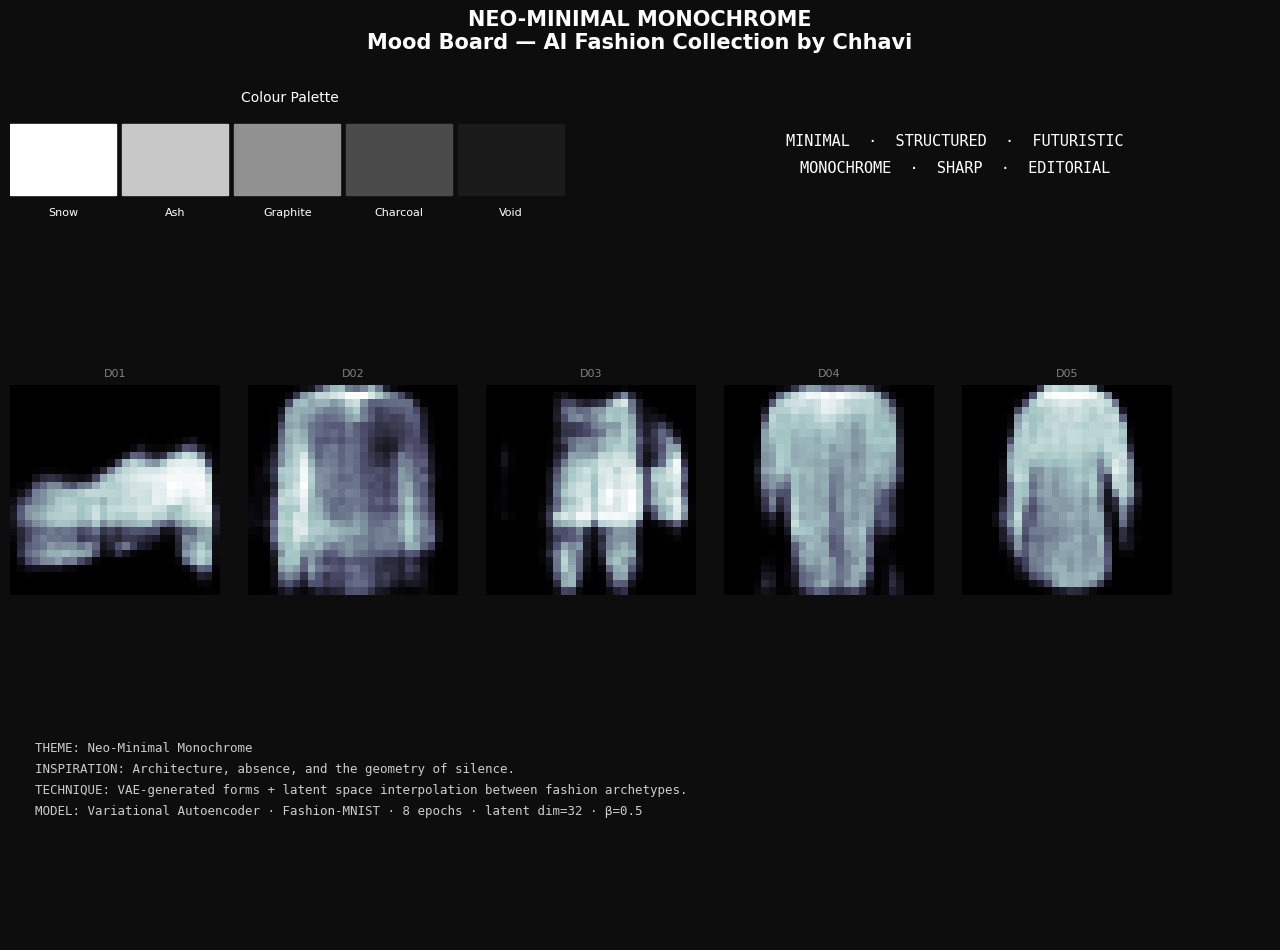

✅ mood_board.png saved


In [ ]:
fig = plt.figure(figsize=(14,10), facecolor='#0d0d0d')
fig.suptitle('NEO-MINIMAL MONOCHROME\nMood Board — AI Fashion Collection by Chhavi',
             fontsize=15, fontweight='bold', color='white', y=0.97)

# Colour palette
ax_p = fig.add_axes([0.05,0.75,0.4,0.12]); ax_p.set_facecolor('#0d0d0d')
for j,(c,l) in enumerate(zip(['#fff','#c8c8c8','#919191','#4a4a4a','#1a1a1a'],
                              ['Snow','Ash','Graphite','Charcoal','Void'])):
    ax_p.add_patch(plt.Rectangle((j*0.2,0),0.19,1,color=c))
    ax_p.text(j*0.2+0.095,-0.3,l,ha='center',color='white',fontsize=8)
ax_p.set_xlim(0,1); ax_p.set_ylim(-0.5,1.2); ax_p.axis('off')
ax_p.set_title('Colour Palette',color='white',fontsize=10)

# Keywords
ax_k = fig.add_axes([0.5,0.75,0.45,0.15]); ax_k.set_facecolor('#0d0d0d')
ax_k.text(0.5,0.5,'MINIMAL  ·  STRUCTURED  ·  FUTURISTIC\nMONOCHROME  ·  SHARP  ·  EDITORIAL',
          ha='center',va='center',color='white',fontsize=11,linespacing=2,fontfamily='monospace')
ax_k.axis('off')

# Designs
for i,(l,b) in enumerate([(0.05,0.3),(0.22,0.3),(0.39,0.3),(0.56,0.3),(0.73,0.3)]):
    ax = fig.add_axes([l,b,0.15,0.38])
    ax.imshow(designs[i].squeeze(), cmap='bone'); ax.axis('off')
    ax.set_title(f'D0{i+1}',color='gray',fontsize=8)

# Notes
ax_n = fig.add_axes([0.05,0.04,0.9,0.22]); ax_n.set_facecolor('#111')
ax_n.text(0.02,0.9,
    'THEME: Neo-Minimal Monochrome\n'
    'INSPIRATION: Architecture, absence, and the geometry of silence.\n'
    'TECHNIQUE: VAE-generated forms + latent space interpolation between fashion archetypes.\n'
    'MODEL: Variational Autoencoder · Fashion-MNIST · 8 epochs · latent dim=32 · β=0.5',
    va='top',color='#ccc',fontsize=9,linespacing=1.8,fontfamily='monospace')
ax_n.axis('off')

plt.savefig('mood_board.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('✅ mood_board.png saved')

---
## ✅ Summary & Creative Process

### Theme: Neo-Minimal Monochrome
Inspired by the idea of stripping fashion to pure geometry — silhouette over decoration.

| Step | Decision | Rationale |
|------|----------|-----------|
| Dataset | Fashion-MNIST | 60K labelled items, 10 classes, lightweight |
| Model | VAE over GAN | Stable training, smooth interpolatable latent space |
| Latent dim | 32 | Rich enough to capture nuance, small enough to regularise |
| β = 0.5 | Beta-VAE | Reduces KL weight → sharper reconstructions |
| Interpolation | Dress → Coat | Reveals hybrid silhouettes across latent space |
| Aesthetic | Bone colormap + dark bg | Reinforces monochrome editorial theme |

---
*Notebook by Chhavi | 2024A7PS0193U*